# **Model 3 Parameters:**
## **Inputs:** SMILES strings of chemical structures and experimental pDC50/Dmax values against ZBTB11 and IKZF1
## **Outputs:** Predicted pDC50 and Dmax values against ZBTB11 and IKZF1
## **Approach:** Multi-target Chemprop v2 with Optuna wrapper for hyperparameter tuning
## **Baseline:** Ridge Regression on Morgan fingerprints
### Semi-Manual splitting of data based on synthesis batch and experimental testing status
* Earlier batch compounds with testing data split in train and validation sets using Chemprop native parser: 85/15% train/validation
* New batch compounds with no testing data separated as test set (prospective evaluation/prediction)
* Increased Optuna trials to 100 and epochs/trial to 50 for better and more consistent hyperparameter identification
* Additionally increased final model training epochs to 100

**Package installs and file loading**

In [1]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/Colab Notebooks/ZBTB11 Degraders/model3"

In [2]:
!pip install optuna lightning chemprop ipywidgets umap-learn matplotlib seaborn 

In [3]:
!pip install torch --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


In [10]:
import pandas as pd
import torch
import optuna
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lightning import pytorch as pl
from chemprop import data, featurizers, models, nn
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from lightning.pytorch.loggers import CSVLogger

**Synthetic Data Generation**

Uncomment code chunk below if you want to test code adjustments with randomly generated dataset

In [5]:
# print("Generating synthetic molecular glue dataset...")

# # 1. Generate 100 valid SMILES strings
# # We use a basic amide-phenyl scaffold and grow an aliphatic chain to create unique molecules
# smiles_list = [f"O=C(Nc1ccccc1)C{'C'*i}" for i in range(1, 41)] + \
#               [f"O=C(Nc1ccc(Cl)cc1)C{'C'*i}" for i in range(1, 31)] + \
#               [f"O=C(Nc1ccc(F)cc1)C{'C'*i}" for i in range(1, 31)]

# df = pd.DataFrame({'SMILES': smiles_list})

# # 2. Assign distinct splits (70 Train / 15 Val / 15 Test)
# df['Dataset'] = ['Train'] * 70 + ['Val'] * 15 + ['Test'] * 15

# # 3. Generate dummy ZBTB11 data
# # pDC50 between 5.0 (10 uM) and 9.0 (1 nM), Dmax between 20% and 100%
# np.random.seed(42) # For reproducible random numbers
# df['ZBTB11_pDC50'] = np.random.uniform(5.0, 9.0, 100)
# df['ZBTB11_Dmax'] = np.random.uniform(20.0, 100.0, 100)

# # 4. Generate dummy IKZF1 data
# df['IKZF1_pDC50'] = np.random.uniform(4.0, 8.0, 100)
# df['IKZF1_Dmax'] = np.random.uniform(0.0, 100.0, 100)

# # 5. Inject 'NaN' values to simulate Inactive Compounds
# # Let's pick 10 random molecules and make them completely inactive against IKZF1
# inactive_indices = np.random.choice(100, 10, replace=False)
# df.loc[inactive_indices, 'IKZF1_Dmax'] = 0.0
# df.loc[inactive_indices, 'IKZF1_pDC50'] = np.nan # This tests Chemprop's masking feature!

# # 6. Save to CSV
# csv_filename = "zbtb11_mgd_input.csv"
# df.to_csv(csv_filename, index=False)

# print(f"Successfully saved 100 test molecules to '{csv_filename}'.")
# print("\nSample of the generated data:")
# print(df.head())

**Chemprop Model Training and Evaluation Pipeline**

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\astartes\main.py:325: ImperfectSplittingWarning: Actual train/test split differs from requested size. Requested train size of 0.85, got 0.86. Requested test size of 0.15, got 0.14. 
  warn(
Dropping last batch of size 1 to avoid issues with batch normalization     (dataset size = 65, batch_size = 64)
[I 2026-03-06 18:30:57,535] A new study created in memory with name: no-name-a2fea085-33c4-4d50-a354-a3f8b3d2cf18
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you sho

Step 1: Parsing explicitly defined Test Set and scaffold-splitting Train/Val...
Split complete! Train: 65, Val: 11, Test (new): 10

Step 2: Running Optuna to find the best model architecture...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │ 35.9 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 20.6 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 56.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 56.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 26                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ message_passing │ BondMessagePassing │  111 K │ train │     0 │
│ 1 │ agg             │ MeanAggregation    │      0 │ train │     0 │
│ 2 │ bn              │ Identity           │      0 │ train │     0 │
│ 3 │ predictor       │ RegressionFFN      │ 41.0 K │ train │     0 │
│ 4 │ X_d_transform   │ Identity           │      0 │ train │     0 │
│ 5 │ metrics         │ ModuleList         │      0 │ train │     0 │
└───┴─────────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 152 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 152 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=100` reached.



Discovered log columns: ['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val/mse', 'val_loss']


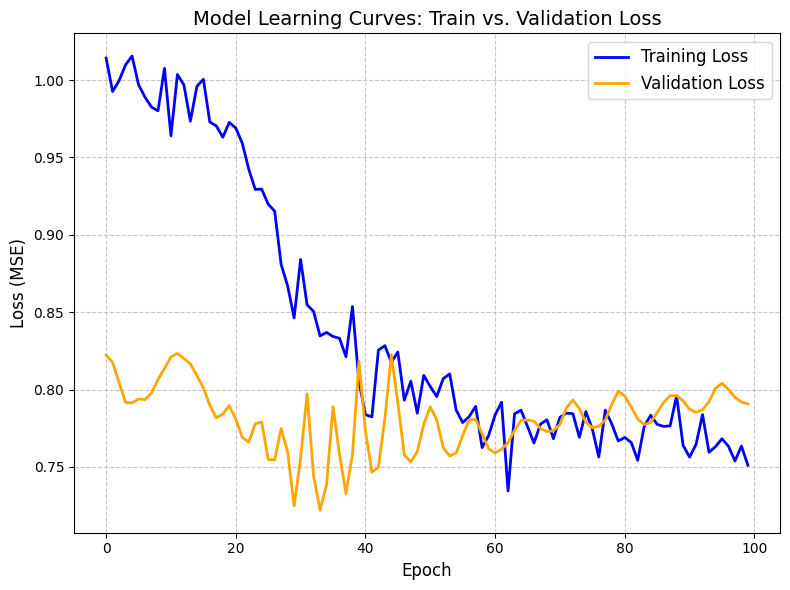

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()


Step 4: Predicting on the Test Set and calculating Efficiency Scores...


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



--- Top Predicted Selective Compounds (Efficiency-based) ---
                                              SMILES  ZBTB11_Efficiency  \
8  O=C1C2=CC=C(NC3=C(NC4(CCC4)C5=CC=C(OC)C=C5)C(C...           0.739032   
5  O=C1CCC(N2C(C(C=CC(NC(N(C)C3(CCC3)C4=CC=C(OC)C...           0.830101   
1  O=C1CCC(N2C(C(C=CC(NC(NC3(CCC3)C4=CC=CC5=C4C=C...           0.736705   
9  O=C1C2=CC=CC(NC(NC3(CCC3)C4=CC=C(OC)C=C4)=O)=C...           1.078438   
0  O=C1CCC(N2C(C(C=CC(NC(NC3(C4=CC=CC(OC5=CC=CC=C...           1.004635   

   IKZF1_Efficiency  Selectivity_Score  
8          2.607641          -1.868609  
5          2.708736          -1.878635  
1          2.621609          -1.884904  
9          2.988548          -1.910109  
0          2.917594          -1.912959  

Step 5: Extracting learned 3D fingerprints from the Chemprop model...
Extracted fingerprints shape: (10, 200)

Step 6: Reducing dimensions with UMAP and plotting...


C:\Users\18589\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


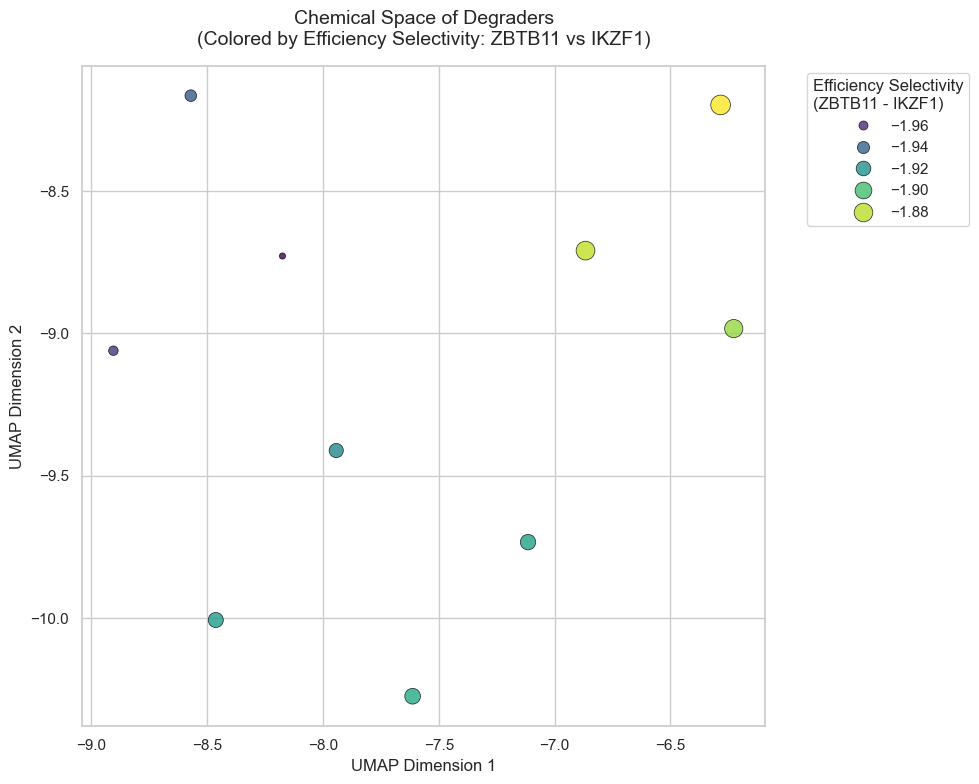


Step 7: Evaluating model performance metrics...

--- Regression Evaluation Metrics ---
    Endpoint  N_Valid_Points   RMSE    MAE     R²  Pearson_r
ZBTB11_pDC50               7  1.448  1.269 -1.962      0.020
 ZBTB11_Dmax              10 22.500 17.383 -0.583     -0.345
 IKZF1_pDC50               8  1.193  1.158 -0.120     -0.154
  IKZF1_Dmax              10 30.946 28.188 -0.346     -0.519

Workflow complete!


In [6]:
# ===================================================================
# STEP 1: LOAD, PARSE, AND SCAFFOLD-SPLIT DATA
# ===================================================================
print("Step 1: Parsing explicitly defined Test Set and scaffold-splitting Train/Val...")

# Load full dataset
df = pd.read_csv("zbtb11_mgd_input.csv")

# 1. Split the DataFrame using Pandas first
# (Assuming you have a column named 'Set' to distinguish the new compounds)
old_df = df[df['Set'] == 'old']
new_df = df[df['Set'] == 'new']

# 2. Parse the old compounds (Train & Validation candidates)
hist_smiles = old_df['SMILES'].tolist()
hist_targets = old_df[['ZBTB11_pDC50', 'ZBTB11_Dmax', 'IKZF1_pDC50', 'IKZF1_Dmax']].values

hist_datapoints = [
    data.MoleculeDatapoint.from_smi(smi, y)
    for smi, y in zip(hist_smiles, hist_targets)
]

# 3. Parse the new compounds (Strict Test Set)
test_smiles = new_df['SMILES'].tolist()
test_targets = new_df[['ZBTB11_pDC50', 'ZBTB11_Dmax', 'IKZF1_pDC50', 'IKZF1_Dmax']].values

test_datapoints = [
    data.MoleculeDatapoint.from_smi(smi, y)
    for smi, y in zip(test_smiles, test_targets)
]

# 4. Scaffold split ONLY the old compounds
# (We pass 0.0 for the test fraction so Chemprop leaves it empty)
hist_mols = [d.mol for d in hist_datapoints]
train_idx, val_idx, _ = data.make_split_indices(
    hist_mols,
    split="scaffold_balanced",
    sizes=(0.85, 0.15, 0.0), # 85% Train, 15% Validation, 0% Test
    seed=42
)

# Apply indices to old datapoints
train_data, val_data, _ = data.split_data_by_indices(
    hist_datapoints, train_idx, val_idx, []
)

train_datapoints = train_data[0]
val_datapoints = val_data[0]
# Note: test_datapoints is already fully defined from our Pandas split!

# 5. Create Datasets with standard Featurizer
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()
train_dset = data.MoleculeDataset(train_datapoints, featurizer)
val_dset = data.MoleculeDataset(val_datapoints, featurizer)
test_dset = data.MoleculeDataset(test_datapoints, featurizer)

# 6. Normalize targets using ONLY the training data stats
output_scaler = train_dset.normalize_targets()
val_dset.normalize_targets(output_scaler)
test_dset.normalize_targets(output_scaler)
output_transform = nn.transforms.UnscaleTransform.from_standard_scaler(output_scaler)

# 7. Build PyTorch DataLoaders
train_loader = data.build_dataloader(train_dset, shuffle=True)
val_loader = data.build_dataloader(val_dset, shuffle=False)
test_loader = data.build_dataloader(test_dset, shuffle=False)

print(f"Split complete! Train: {len(train_dset)}, Val: {len(val_dset)}, Test (new): {len(test_dset)}")


# ===================================================================
# STEP 2: HYPERPARAMETER TUNING WITH OPTUNA
# ===================================================================
print("\nStep 2: Running Optuna to find the best model architecture...")

def objective(trial):
    depth = trial.suggest_int("depth", 2, 6)
    d_h = trial.suggest_int("d_h", 100, 300, step=100)
    dropout = trial.suggest_float("dropout", 0.2, 0.5, step=0.1)
    n_layers = trial.suggest_int("n_layers", 1, 3)

    mp = nn.BondMessagePassing(depth=depth, d_h=d_h)
    agg = nn.MeanAggregation()

    ffn = nn.RegressionFFN(
        n_tasks=4,
        input_dim=mp.output_dim,
        hidden_dim=d_h,
        n_layers=n_layers,
        dropout=dropout,
        output_transform=output_transform
    )
    chemprop_model = models.MPNN(mp, agg, ffn)

    trainer = pl.Trainer(
        accelerator="auto", # Automatically uses GPU if available
        max_epochs=50,
        enable_checkpointing=False,
        enable_progress_bar=False,
        logger=False
    )
    trainer.fit(chemprop_model, train_loader, val_loader)

    return trainer.callback_metrics["val_loss"].item()

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
print(f"Best hyperparameters found: {study.best_params}")


# ===================================================================
# STEP 3: TRAIN FINAL MODEL & PLOT LOSS CURVES
# ===================================================================
print("\nStep 3: Training the final model and monitoring loss...")

best = study.best_params

final_mp = nn.BondMessagePassing(depth=best["depth"], d_h=best["d_h"])
final_agg = nn.MeanAggregation()

final_ffn = nn.RegressionFFN(
    n_tasks=4,
    input_dim=final_mp.output_dim,
    hidden_dim=best["d_h"],
    n_layers=best["n_layers"],
    dropout=best["dropout"],
    output_transform=output_transform
)
final_model = models.MPNN(final_mp, final_agg, final_ffn)

# 1. Set up the CSV Logger
logger = CSVLogger("training_logs", name="chemprop_model")

final_trainer = pl.Trainer(
    accelerator="auto",
    max_epochs=100,
    logger=logger, # <--- Attach the logger here
    enable_progress_bar=True,
    enable_checkpointing=True
)

# Train the model
final_trainer.fit(final_model, train_loader, val_loader)

# 2. Extract and Plot the Loss Curves
metrics_file = f"{logger.log_dir}/metrics.csv"
metrics_df = pd.read_csv(metrics_file)

print(f"\nDiscovered log columns: {metrics_df.columns.tolist()}")

# Dynamically find the correct column names for train and val loss
train_cols = [c for c in metrics_df.columns if 'train' in c.lower() and 'loss' in c.lower()]
val_cols = [c for c in metrics_df.columns if 'val' in c.lower() and 'loss' in c.lower()]

# Chemprop sometimes logs training loss simply as 'loss'
train_col = train_cols[0] if train_cols else ('loss' if 'loss' in metrics_df.columns else None)
val_col = val_cols[0] if val_cols else None

if train_col and val_col:
    # Group by epoch and drop NaNs (since Lightning logs train/val on different rows)
    train_loss = metrics_df[['epoch', train_col]].dropna().groupby('epoch').mean()
    val_loss = metrics_df[['epoch', val_col]].dropna().groupby('epoch').mean()

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(train_loss.index, train_loss[train_col], label='Training Loss', color='blue', linewidth=2)
    plt.plot(val_loss.index, val_loss[val_col], label='Validation Loss', color='orange', linewidth=2)

    plt.title("Model Learning Curves: Train vs. Validation Loss", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss (MSE)", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300)
    plt.show()
else:
    print("\nError: Could not find both train and validation loss columns in the logs.")

# ===================================================================
# STEP 4: PREDICT & CALCULATE DEGRADATION EFFICIENCY SCORE
# ===================================================================
print("\nStep 4: Predicting on the Test Set and calculating Efficiency Scores...")

preds = final_trainer.predict(final_model, test_loader)
preds_tensor = torch.concat(preds, axis=0)

test_results_df = pd.DataFrame(
    preds_tensor.numpy(),
    columns=[
        'Pred_ZBTB11_pDC50', 'Pred_ZBTB11_Dmax',
        'Pred_IKZF1_pDC50', 'Pred_IKZF1_Dmax'
    ]
)

# Extract SMILES dynamically from the test datapoints
test_smiles = [dp.name for dp in test_datapoints]
test_results_df.insert(0, 'SMILES', test_smiles)

# Calculate Degradation Efficiency
test_results_df['ZBTB11_Efficiency'] = test_results_df['Pred_ZBTB11_pDC50'] * (test_results_df['Pred_ZBTB11_Dmax'] / 100)
test_results_df['IKZF1_Efficiency'] = test_results_df['Pred_IKZF1_pDC50'] * (test_results_df['Pred_IKZF1_Dmax'] / 100)

# Final Selectivity Score
test_results_df['Selectivity_Score'] = test_results_df['ZBTB11_Efficiency'] - test_results_df['IKZF1_Efficiency']

test_results_df = test_results_df.sort_values(by='Selectivity_Score', ascending=False)
print("\n--- Top Predicted Selective Compounds (Efficiency-based) ---")
print(test_results_df[['SMILES', 'ZBTB11_Efficiency', 'IKZF1_Efficiency', 'Selectivity_Score']].head())
test_results_df.to_csv("zbtb11_mgd_chemprop_output.csv", index=False)


# ===================================================================
# STEP 5: EXTRACT LEARNED FINGERPRINTS FROM THE MODEL
# ===================================================================
print("\nStep 5: Extracting learned 3D fingerprints from the Chemprop model...")

# Bring model to CPU for frictionless extraction from batch structures
final_model.cpu()
final_model.eval()

learned_fingerprints = []

with torch.no_grad():
    for batch in test_loader:
        molecule_embeddings = final_model.fingerprint(batch.bmg, batch.V_d, batch.X_d)
        learned_fingerprints.append(molecule_embeddings.numpy())

embeddings_array = np.vstack(learned_fingerprints)
print(f"Extracted fingerprints shape: {embeddings_array.shape}")


# ===================================================================
# STEP 6: UMAP DIMENSIONALITY REDUCTION & PLOTTING
# ===================================================================
print("\nStep 6: Reducing dimensions with UMAP and plotting...")

reducer = umap.UMAP(n_neighbors=min(15, len(embeddings_array) - 1), min_dist=0.1, metric='euclidean', random_state=42)
embeddings_2d = reducer.fit_transform(embeddings_array)

# Re-sort results dataframe by original index to align with extracted embeddings
test_results_df = test_results_df.sort_index()

test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=test_results_df,
    x='UMAP_1',
    y='UMAP_2',
    hue='Selectivity_Score',
    palette='viridis',
    size='Selectivity_Score',
    sizes=(20, 200),
    alpha=0.8,
    edgecolor="black"
)

plt.title("Chemical Space of Degraders\n(Colored by Efficiency Selectivity: ZBTB11 vs IKZF1)", fontsize=14, pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Efficiency Selectivity\n(ZBTB11 - IKZF1)")
plt.tight_layout()
plt.savefig("chemprop_umap.png", dpi=300, bbox_inches='tight')
plt.show()


# ===================================================================
# STEP 7: EVALUATE REGRESSION METRICS
# ===================================================================
print("\nStep 7: Evaluating model performance metrics...")


true_cols = ['ZBTB11_pDC50', 'ZBTB11_Dmax', 'IKZF1_pDC50', 'IKZF1_Dmax']
pred_cols = ['Pred_ZBTB11_pDC50', 'Pred_ZBTB11_Dmax', 'Pred_IKZF1_pDC50', 'Pred_IKZF1_Dmax']

# Extract true targets dynamically from test datapoints
y_true_array = np.array([dp.y for dp in test_datapoints])
evaluation_results = []

for idx, (true_col, pred_col) in enumerate(zip(true_cols, pred_cols)):
    y_true = y_true_array[:, idx]
    y_pred = test_results_df[pred_col].values

    # Mask NaNs
    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid_Points': len(y_true_valid),
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R²': round(r2, 3),
        'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_chemprop_metrics.csv", index=False)
print("\n--- Regression Evaluation Metrics ---")
print(metrics_df.to_string(index=False))
print("\nWorkflow complete!")

**Ridge Regression Model Training and Evaluation Pipeline**

Step 1: Splitting data and generating Morgan Fingerprints...

Step 2 & 3: Training independent Ridge Regression models for each target...
[ZBTB11_pDC50] Best Regularization (Alpha): 1000.0 | Trained on 54 compounds.
[ZBTB11_Dmax] Best Regularization (Alpha): 100.0 | Trained on 76 compounds.
[IKZF1_pDC50] Best Regularization (Alpha): 100.0 | Trained on 64 compounds.
[IKZF1_Dmax] Best Regularization (Alpha): 100.0 | Trained on 74 compounds.

Step 4: Predicting on the Test Set and calculating Efficiency Scores...

--- Top Predicted Selective Compounds (Ridge Baseline) ---
                                               SMILES  ZBTB11_Efficiency  \
81  O=C1CCC(N2C(C(C=CC(NC(N(C)C3(CCC3)C4=CC=C(OC)C...           1.469300   
82  COC1=CC=C(C2(CCC2)NS(NC3=CC(C4)=C(C=C3)C(N4C(C...           1.787598   
84  O=C1C2=CC=C(NC3=C(NC4(CCC4)C5=CC=C(OC)C=C5)C(C...           1.805970   
79  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)CNCC4=CC=CC=C4...           1.566330   
80  O=C1CCC(N2C(C(C=CC(NC(NC3(CCCC3)CNCC4=CC

[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerator
[18:35:31] DEPRECATION WARNING: please use MorganGenerat

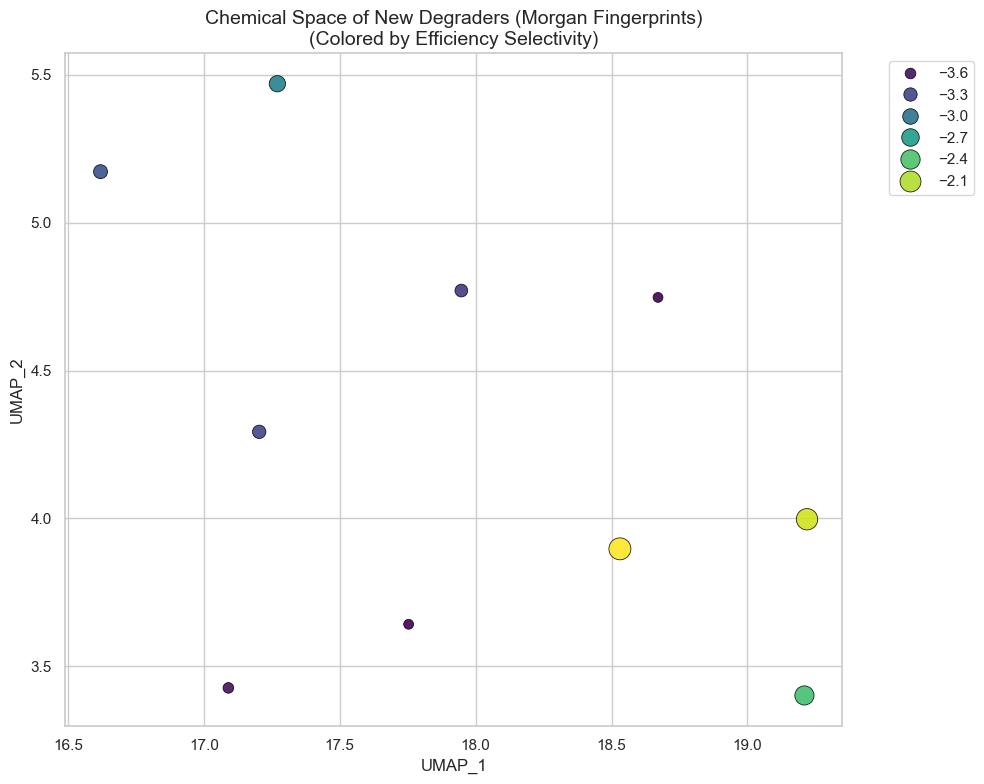


Step 7: Evaluating Ridge Baseline performance metrics...

--- Baseline Regression Metrics ---
    Endpoint  N_Valid   RMSE    MAE     R²  Pearson_r
ZBTB11_pDC50        7  1.106  0.996 -0.727      0.772
 ZBTB11_Dmax       10 16.132 14.084  0.186      0.518
 IKZF1_pDC50        8  0.944  0.853  0.299      0.626
  IKZF1_Dmax       10 27.692 21.261 -0.078      0.319


In [7]:
# ===================================================================
# HELPER FUNCTION: GENERATE MORGAN FINGERPRINTS
# ===================================================================
def smiles_to_morgan(smiles_list, radius=2, n_bits=2048):
    """Converts a list of SMILES strings to 2048-bit Morgan Fingerprints."""
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fps.append(np.array(fp))
        else:
            fps.append(np.zeros((n_bits,))) # Fallback for invalid SMILES
    return np.array(fps)

# ===================================================================
# STEP 1: PARSE, SPLIT, AND FEATURIZE DATA
# ===================================================================
print("Step 1: Splitting data and generating Morgan Fingerprints...")

df = pd.read_csv("zbtb11_mgd_input.csv")

# Split into Train/Test explicitly using your 'Set' column
# (UPDATED to use 'old' and 'new' strings)
train_df = df[df['Set'] == 'old'].copy()
test_df = df[df['Set'] == 'new'].copy()

# Generate 2048-bit Morgan Fingerprints (Features / X)
X_train = smiles_to_morgan(train_df['SMILES'].tolist())
X_test = smiles_to_morgan(test_df['SMILES'].tolist())

# We must standardize our features for Ridge Regression to work properly
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

targets = ['ZBTB11_pDC50', 'ZBTB11_Dmax', 'IKZF1_pDC50', 'IKZF1_Dmax']

# ===================================================================
# STEP 2 & 3: TRAIN MULTIPLE MODELS (HANDLING NaNs)
# ===================================================================
print("\nStep 2 & 3: Training independent Ridge Regression models for each target...")

# Dictionary to hold our 4 trained models
trained_models = {}

# We will test these regularization strengths automatically (replaces Optuna)
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]

for target in targets:
    # 1. Extract the specific target array
    y_train = train_df[target].values

    # 2. Create a mask to filter out NaNs (Inactive compounds)
    valid_mask = ~np.isnan(y_train)

    X_train_valid = X_train_scaled[valid_mask]
    y_train_valid = y_train[valid_mask]

    # 3. Train the model (RidgeCV automatically finds the best alpha using cross-validation)
    model = RidgeCV(alphas=alphas, cv=5)
    model.fit(X_train_valid, y_train_valid)

    trained_models[target] = model
    print(f"[{target}] Best Regularization (Alpha): {model.alpha_} | Trained on {len(y_train_valid)} compounds.")

# ===================================================================
# STEP 4: PREDICT ON TEST SET & CALCULATE EFFICIENCY
# ===================================================================
print("\nStep 4: Predicting on the Test Set and calculating Efficiency Scores...")

# Create a DataFrame to hold predictions
test_results_df = test_df[['SMILES'] + targets].copy()

# Predict using the 4 independent models
for target in targets:
    pred_col_name = f'Pred_{target}'
    test_results_df[pred_col_name] = trained_models[target].predict(X_test_scaled)

# Calculate Degradation Efficiency
test_results_df['ZBTB11_Efficiency'] = test_results_df['Pred_ZBTB11_pDC50'] * (test_results_df['Pred_ZBTB11_Dmax'] / 100)
test_results_df['IKZF1_Efficiency'] = test_results_df['Pred_IKZF1_pDC50'] * (test_results_df['Pred_IKZF1_Dmax'] / 100)

test_results_df['Selectivity_Score'] = test_results_df['ZBTB11_Efficiency'] - test_results_df['IKZF1_Efficiency']

test_results_df = test_results_df.sort_values(by='Selectivity_Score', ascending=False)
print("\n--- Top Predicted Selective Compounds (Ridge Baseline) ---")
print(test_results_df[['SMILES', 'ZBTB11_Efficiency', 'IKZF1_Efficiency', 'Selectivity_Score']].head())
test_results_df.to_csv("zbtb11_mgd_ridge_output.csv", index=False)

# ===================================================================
# STEP 5 & 6: UMAP PLOTTING
# ===================================================================
print("\nStep 5 & 6: Reducing Morgan fingerprints with UMAP and plotting...")

# Use the fixed Morgan fingerprints for the UMAP
reducer = umap.UMAP(n_neighbors=min(5, len(X_test) - 1), min_dist=0.1, metric='jaccard', random_state=42)
embeddings_2d = reducer.fit_transform(X_test)

test_results_df = test_results_df.sort_index()
test_results_df['UMAP_1'] = embeddings_2d[:, 0]
test_results_df['UMAP_2'] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(
    data=test_results_df, x='UMAP_1', y='UMAP_2',
    hue='Selectivity_Score', palette='viridis',
    size='Selectivity_Score', sizes=(50, 250), alpha=0.9, edgecolor="black"
)
plt.title("Chemical Space of New Degraders (Morgan Fingerprints)\n(Colored by Efficiency Selectivity)", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("ridge_umap.png", dpi=300, bbox_inches='tight')
plt.show()

# ===================================================================
# STEP 7: EVALUATE REGRESSION METRICS
# ===================================================================
print("\nStep 7: Evaluating Ridge Baseline performance metrics...")

evaluation_results = []
pred_cols = [f'Pred_{t}' for t in targets]

for true_col, pred_col in zip(targets, pred_cols):
    y_true = test_results_df[true_col].values
    y_pred = test_results_df[pred_col].values

    valid_mask = ~np.isnan(y_true)
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    if len(y_true_valid) > 1:
        rmse = np.sqrt(mean_squared_error(y_true_valid, y_pred_valid))
        mae = mean_absolute_error(y_true_valid, y_pred_valid)
        r2 = r2_score(y_true_valid, y_pred_valid)
        pearson_r, _ = pearsonr(y_true_valid, y_pred_valid)
    else:
        rmse, mae, r2, pearson_r = np.nan, np.nan, np.nan, np.nan

    evaluation_results.append({
        'Endpoint': true_col,
        'N_Valid': len(y_true_valid),
        'RMSE': round(rmse, 3), 'MAE': round(mae, 3),
        'R²': round(r2, 3), 'Pearson_r': round(pearson_r, 3)
    })

metrics_df = pd.DataFrame(evaluation_results)
metrics_df.to_csv("zbtb11_mgd_ridge_metrics.csv", index=False)
print("\n--- Baseline Regression Metrics ---")
print(metrics_df.to_string(index=False))